# Machine Learning with Python

## Simple Linear Regression

### 📌 Project Overview

This lab demonstrates how to build a Simple Linear Regression model using Scikit-learn to predict CO2 emissions based on vehicle features such as:

- Engine Size
- Fuel Consumption
- Cylinders

The project covers:

- Data exploration
- Data visualization
- Train/Test splitting
- Model training
- Prediction
- Model evaluation

### 📚 Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

- NumPy → Numerical operations and array handling
- Pandas → Data analysis and manipulation
- Matplotlib → Data visualization

### 📂 Load the Dataset

In [2]:
path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv'
df = pd.read_csv(path)

Load the CSV dataset into a Pandas DataFrame.

### 🔍 Explore the Dataset

In [4]:
# Optional: df.head() df.isnull()  df.sample(10)
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


### 🎯 Select Relevant Features

In [6]:
cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB','CO2EMISSIONS']]

Selected features:
- ENGINESIZE
- CYLINDERS
- FUELCONSUMPTION_COMB

Target variable:

- CO2EMISSIONS

### 📊 Data Visualization

#### Histogram Visualization

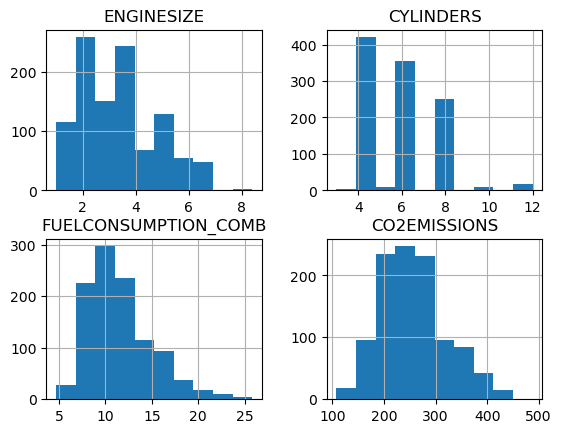

In [7]:
cdf.hist()
plt.show()

Histograms help visualize the distribution of each feature.

### Fuel Consumption vs CO2 Emissions

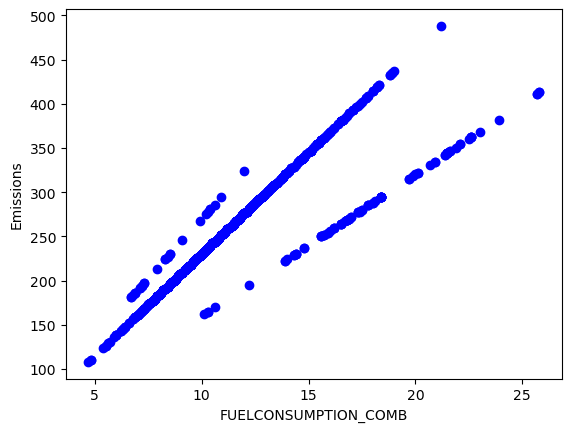

In [9]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('FUELCONSUMPTION_COMB')
plt.ylabel('Emissions')

plt.show()

This scatter plot shows the relationship between fuel consumption and CO2 emissions.

### Engine Size vs CO2 Emissions

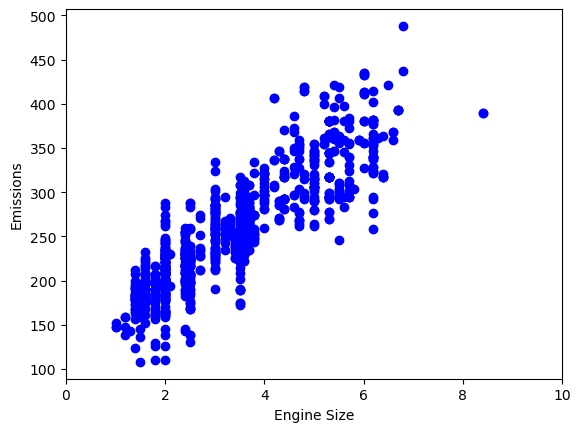

In [13]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('Engine Size')
plt.ylabel('Emissions')

# To slim the X axis(Engine Size):
plt.xlim(0,10)
plt.show()


This visualization helps identify whether a linear relationship exists between engine size and CO2 emissions.

### 🔄 Prepare the Data

In [15]:
x = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

Convert Pandas columns into NumPy arrays for compatibility with Scikit-learn.

### ✂️ Split Training and Testing Data

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

Dataset split:

- 80% Training Data
- 20% Testing Data

### 🤖 Build the Linear Regression Model

In [17]:
from sklearn import linear_model

regressor = linear_model.LinearRegression()

Create a Linear Regression model object.

### 🏋️ Train the Model

In [19]:
regressor.fit(x_train.reshape(-1,1), y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


We use the (reshape(-1,1)) because the scikit-learn accepts a 2D array and the (x_train) is a 1D array

### 📈 Model Parameters

In [22]:
print('Coefficients: ', regressor.coef_[0])
print('Intercept: ', regressor.intercept_)

Coefficients:  38.99297872443407
Intercept:  126.28970217408724


- Coefficient → Slope of the regression line
- Intercept → Starting point of the regression line

### Regression Equation:

y = mx + b

### 📉 Visualize the Regression Line

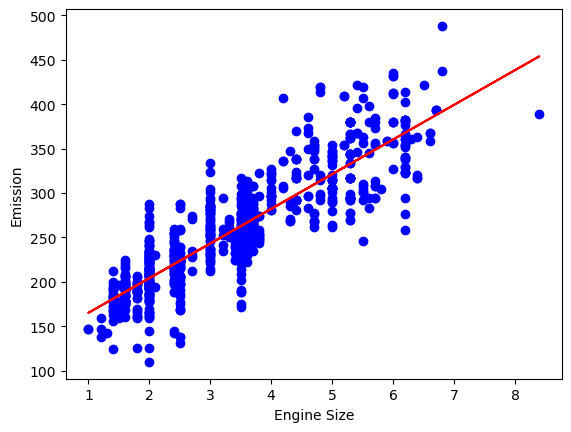

In [25]:
plt.scatter(x_train, y_train, color='blue')
plt.plot(x_train, regressor.coef_ * x_train + regressor.intercept_, color='red')
plt.xlabel('Engine Size')
plt.ylabel('Emission')

plt.show()

- Blue points → Training data
- Red line → Regression model prediction

### 🔮 Make Predictions

In [26]:
y_pred = regressor.predict(x_test.reshape(-1,1))

Use the trained model to predict CO2 emissions for the testing dataset.

### 📏 Evaluate the Model

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Mean absolute error: %.2f'% mean_absolute_error(y_test, y_pred))
print('Mean squared error: %.2f' %mean_squared_error(y_test, y_pred))
print('Room mean squared error: %.2f' % np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2-score: %.2f' % r2_score(y_test, y_pred))

Mean absolute error: 24.10
Mean squared error: 985.94
Room mean squared error: 31.40
R2-score: 0.76


#### Evaluation Metrics
- MAE → Average prediction error
- MSE → Squared prediction error
- RMSE → Root mean squared error
- R² Score → Model performance score

### 📊 Test Data Visualization

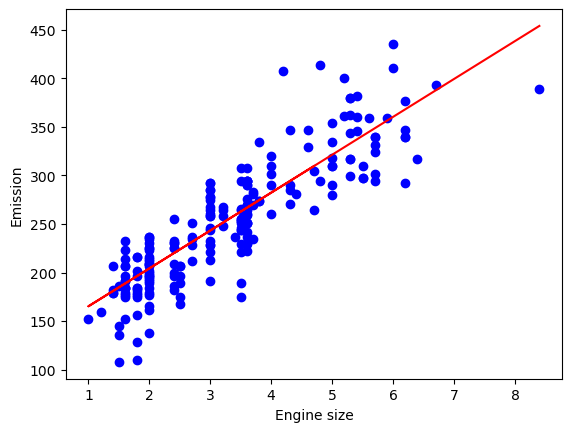

In [30]:
plt.scatter(x_test, y_test, color='blue')
plt.plot(x_test, regressor.coef_ * x_test + regressor.intercept_, 'red')
plt.xlabel("Engine size")
plt.ylabel("Emission")

plt.show()

### ⛽ Alternative Feature: Fuel Consumption

In [32]:
X = cdf.FUELCONSUMPTION_COMB.to_numpy()

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regr = linear_model.LinearRegression()
regr.fit(x_train.reshape(-1,1),y_train)

y_pred = regr.predict(x_test.reshape(-1,1))

print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))

Mean squared error: 797.43


This section trains another Linear Regression model using:

- FUELCONSUMPTION_COMB

instead of:

- ENGINESIZE

to compare model performance.

### ✅ Conclusion

In this lab, we successfully:

- Explored and visualized the dataset
- Built a Simple Linear Regression model
- Trained and tested the model
- Evaluated prediction performance
- Compared different input features

This project demonstrates the fundamental workflow of supervised machine learning using Linear Regression.